In [251]:
import warnings
warnings.filterwarnings("ignore")
!pip install imbalanced-learn

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Options
pd.set_option("display.max_columns", None)

print("=" * 60)
print("✅ Libraries Imported Successfully")
print("=" * 60)

✅ Libraries Imported Successfully


In [252]:
# ======================================================
# STEP 2 : Upload Dataset
# ======================================================



df = pd.read_csv("Telco_customer_churn.csv")

print("=" * 60)
print("✅ Dataset Loaded Successfully")
print("=" * 60)

✅ Dataset Loaded Successfully


In [253]:
print(df.shape)

(7043, 33)


In [254]:
# ======================================================
# STEP 3 : Basic Information
# ======================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Dataset Shape
Rows    : 7043
Columns : 33

Column Names:

1. CustomerID
2. Count
3. Country
4. State
5. City
6. Zip Code
7. Lat Long
8. Latitude
9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


In [255]:
print(df.shape)

(7043, 33)


In [256]:
# ======================================================
# STEP 4 : Preview Dataset
# ======================================================

print("First 5 Rows")

display(df.head())

print("\nLast 5 Rows")

display(df.tail())

First 5 Rows


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices



Last 5 Rows


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [257]:
print(df.shape)

(7043, 33)


In [258]:
# ======================================================
# STEP 5 : Dataset Information
# ======================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [259]:
print(df.shape)

(7043, 33)


In [260]:
# ======================================================
# STEP 6 : Statistical Summary
# ======================================================

display(df.describe())

display(df.describe(include="object"))

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174,192


In [261]:
print(df.shape)

(7043, 33)


In [262]:
# ======================================================
# STEP 7 : Missing Values
# ======================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

display(missing)

print("\nTotal Missing Values :", df.isnull().sum().sum())

Churn Reason    5174
dtype: int64


Total Missing Values : 5174


In [263]:
print(df.shape)

(7043, 33)


In [264]:
# ======================================================
# STEP 8 : Duplicate Values
# ======================================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [265]:
print(df.shape)

(7043, 33)


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


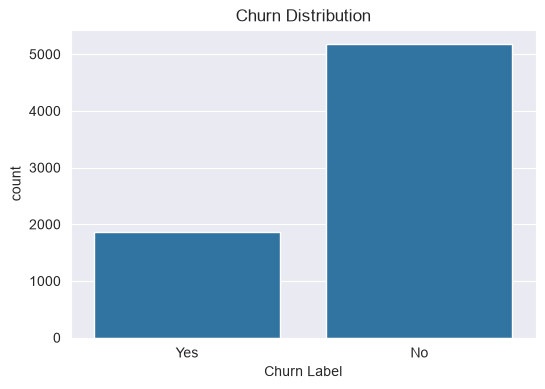

In [266]:
# ======================================================
# STEP 9 : Target Variable
# ======================================================

print(df["Churn Label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn Label")

plt.title("Churn Distribution")

plt.show()

In [267]:
# ======================================================
# STEP 10 : Check Data Types
# ======================================================

display(df.dtypes)

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [268]:
# ======================================================
# STEP 11 : Convert Total Charges
# ======================================================

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

print(df["Total Charges"].dtype)

float64


In [269]:
print(df.shape)

(7043, 33)


In [270]:
# ======================================================
# STEP 12 : Missing Values After Conversion
# ======================================================

missing = df.isnull().sum()

display(missing[missing > 0])

Total Charges      11
Churn Reason     5174
dtype: int64

In [271]:
print(df.shape)

(7043, 33)


In [272]:
# ======================================================
# STEP 13 : Handle Missing Values
# ======================================================

# Remove only rows where Total Charges is missing
df.dropna(subset=["Total Charges"], inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (7032, 33)


In [273]:
print(df.shape)

(7032, 33)


In [274]:
# ======================================================
# STEP 14 : Check Customer IDs
# ======================================================

print("Unique Customer IDs :", df["CustomerID"].nunique())

print("Total Rows :", len(df))

Unique Customer IDs : 7032
Total Rows : 7032


In [275]:
print(df.shape)

(7032, 33)


In [276]:
# ======================================================
# STEP 15 : Remove Leakage Columns
# ======================================================

drop_columns = [
    "CustomerID",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

df.drop(columns=drop_columns, inplace=True)

print("Columns Removed Successfully")

Columns Removed Successfully


In [277]:
print(df.shape)

(7032, 29)


In [278]:
# ======================================================
# STEP 16 : Remaining Columns
# ======================================================

print(df.columns)

print("\nNumber of Columns :", len(df.columns))

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV'],
      dtype='str')

Number of Columns : 29


In [279]:
print(df.shape)

(7032, 29)


In [280]:
# ======================================================
# STEP 17 : Features & Target
# ======================================================

X = df.drop("Churn Value", axis=1)

y = df["Churn Value"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (7032, 28)
Target Shape : (7032,)


In [281]:
print(df.shape)

(7032, 29)


In [282]:
# ======================================================
# STEP 18 : Target Balance
# ======================================================

print(y.value_counts())

print()

print(y.value_counts(normalize=True) * 100)

Churn Value
0    5163
1    1869
Name: count, dtype: int64

Churn Value
0    73.421502
1    26.578498
Name: proportion, dtype: float64


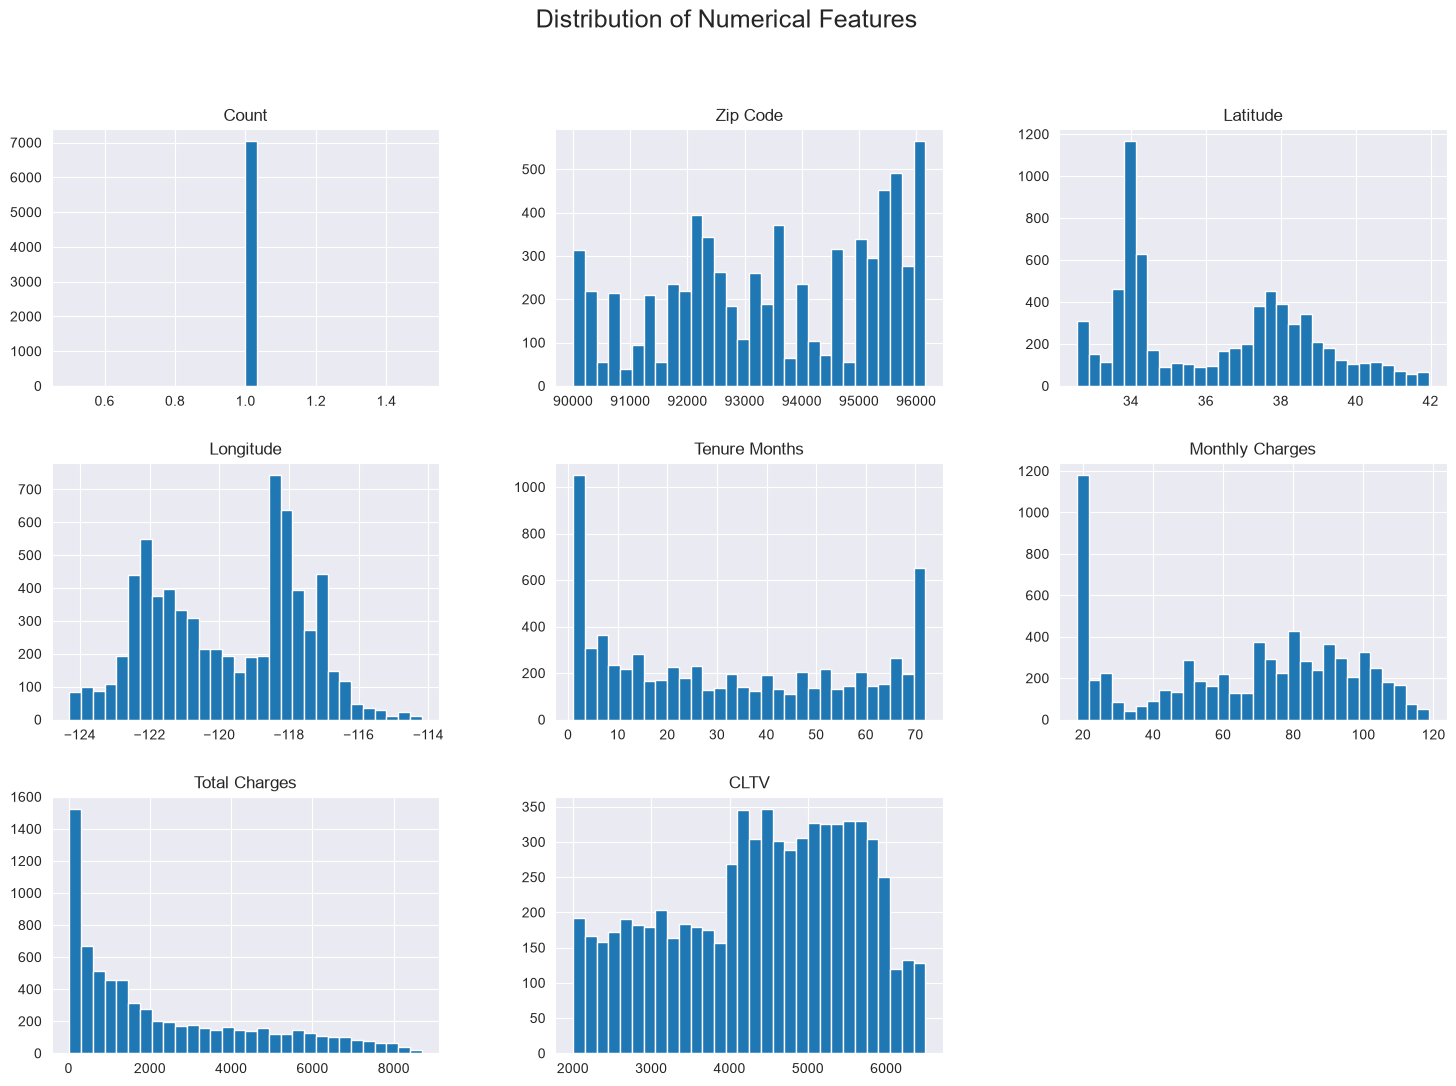

In [283]:
# ======================================================
# STEP 19 : Distribution of Numerical Features
# ======================================================

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

X[numerical_columns].hist(figsize=(18,12), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.show()

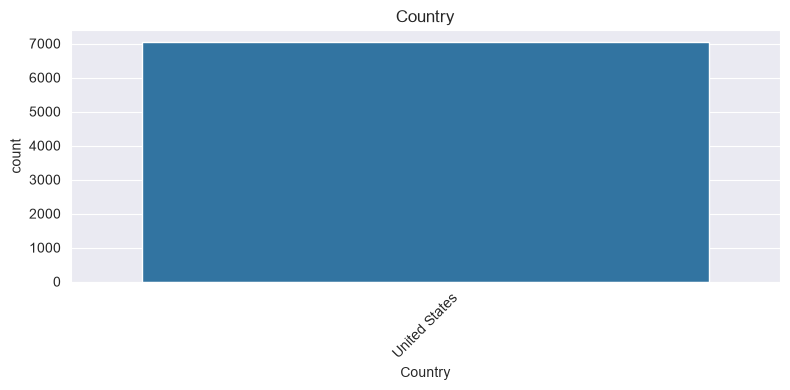

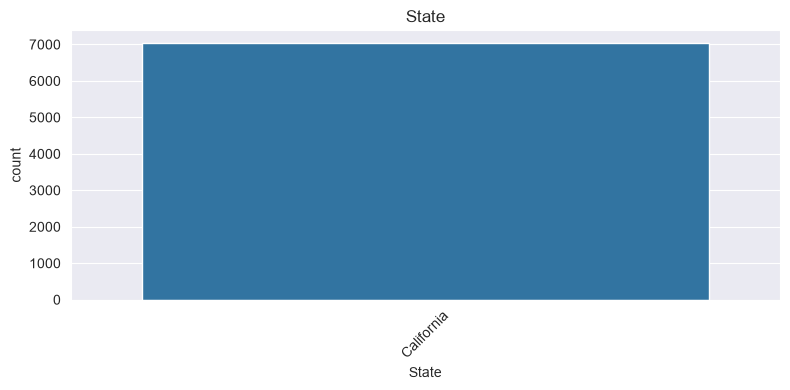

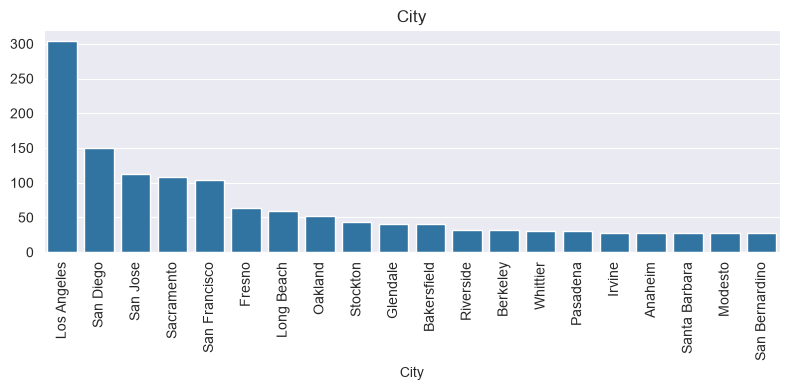

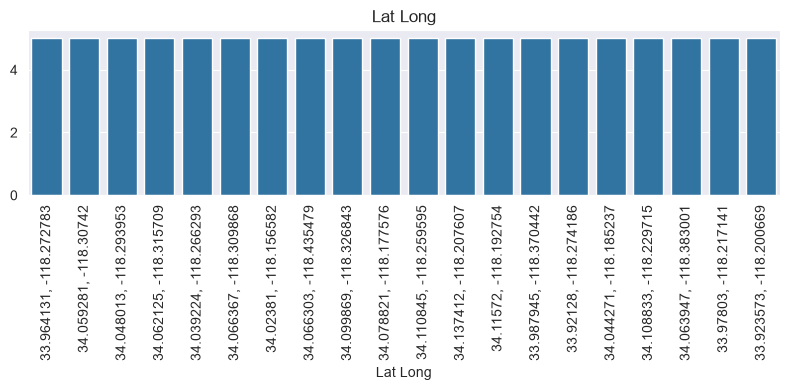

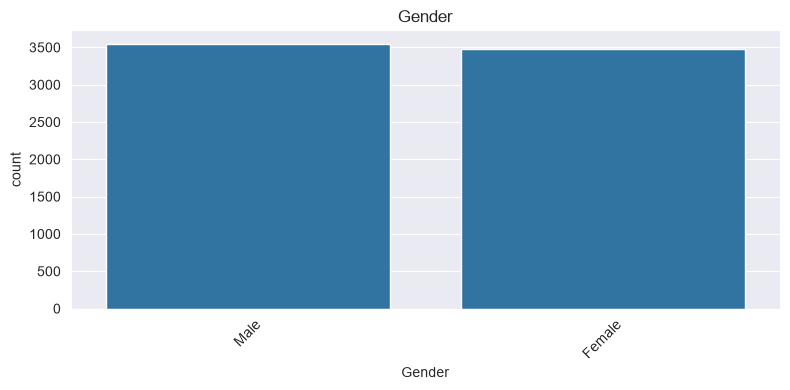

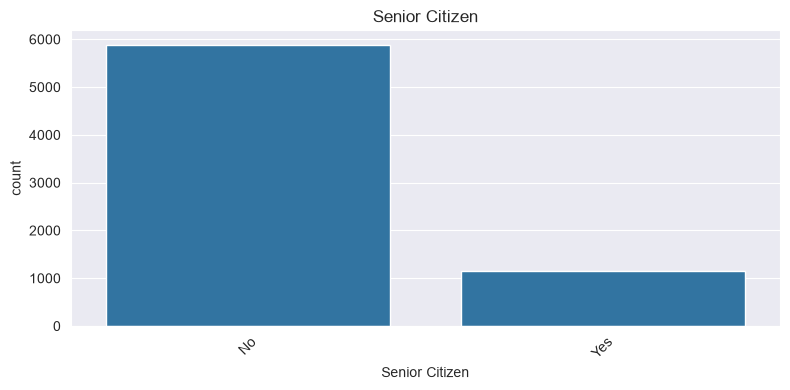

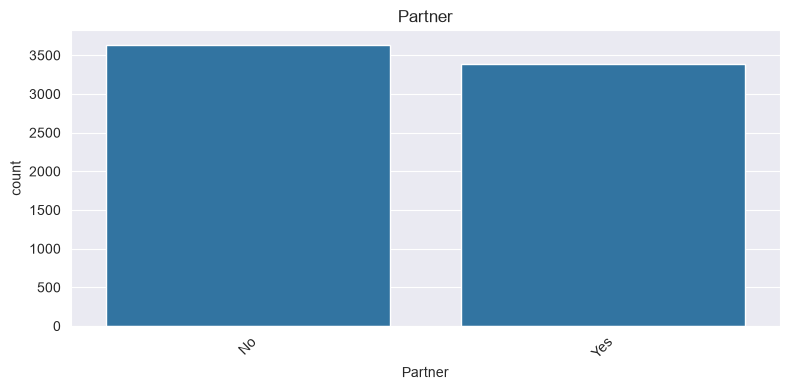

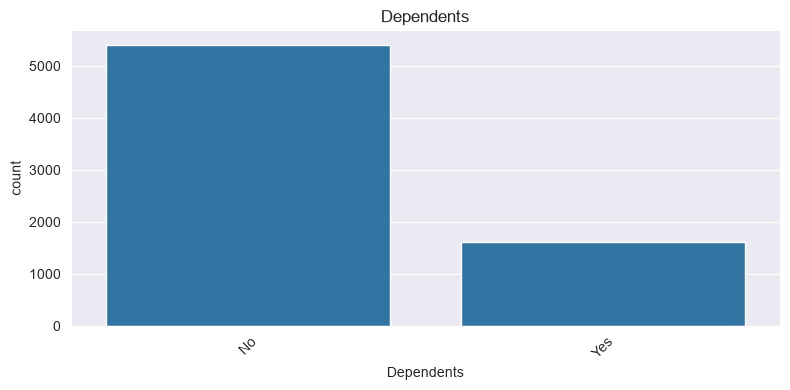

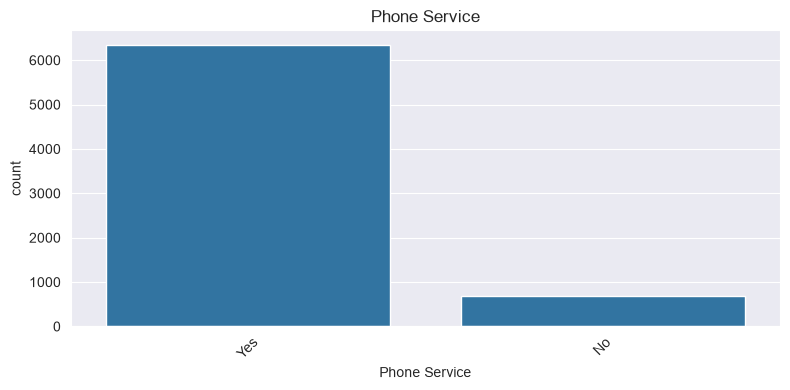

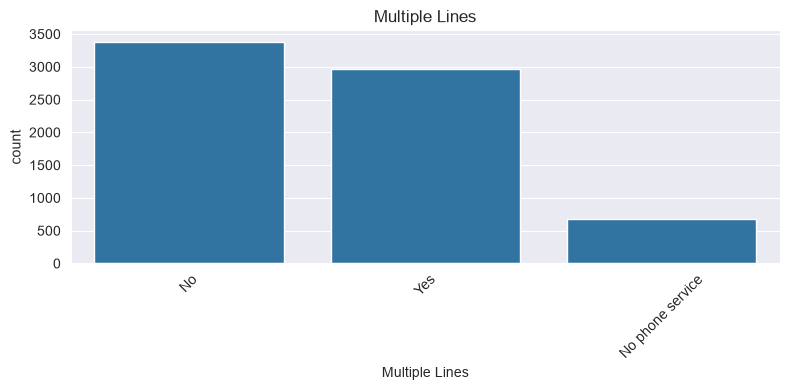

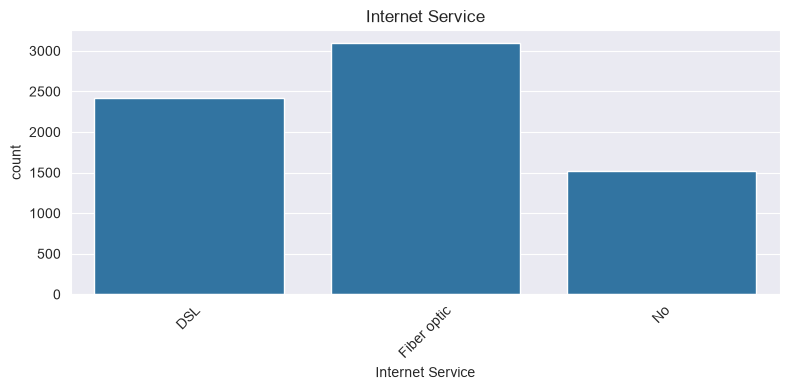

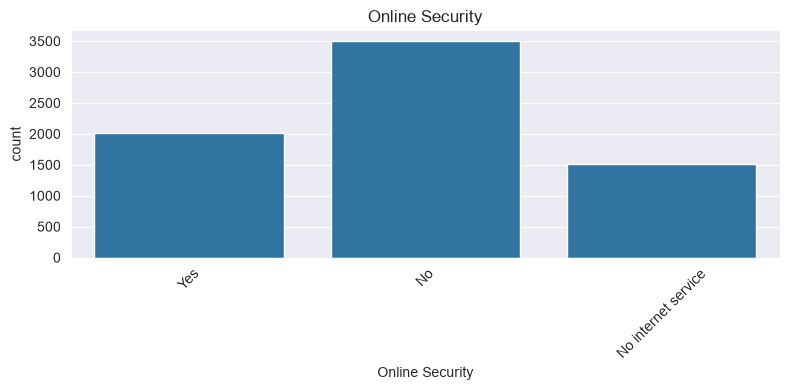

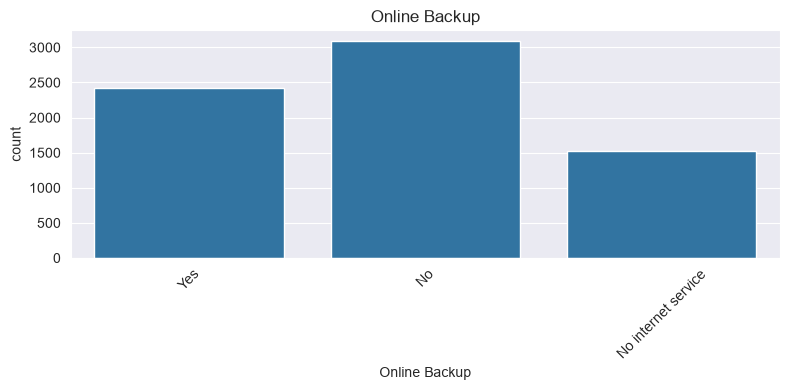

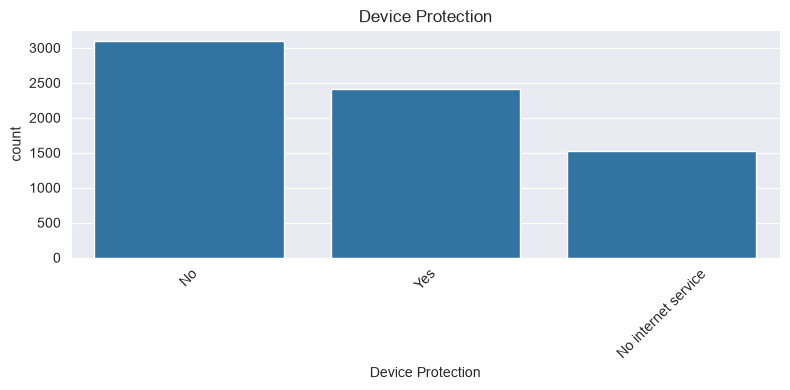

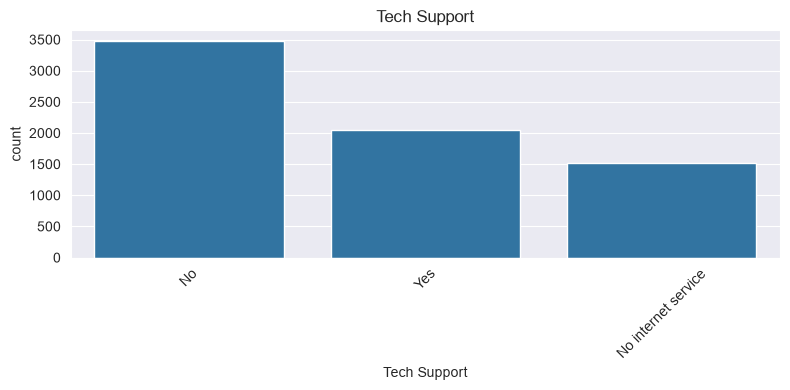

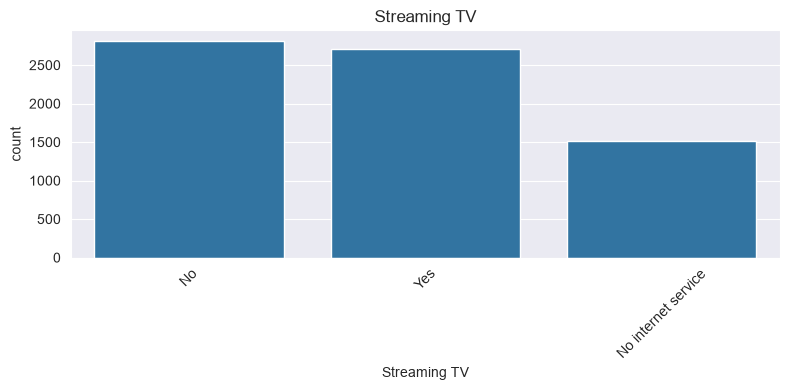

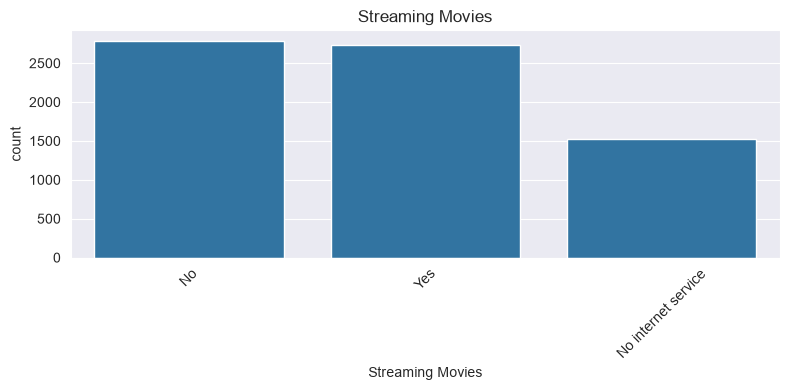

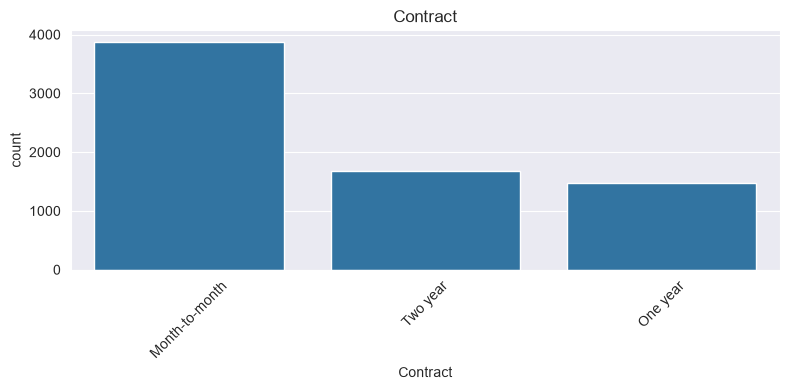

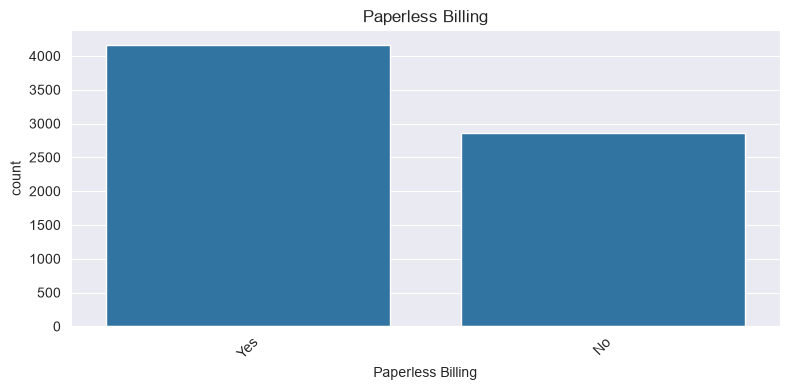

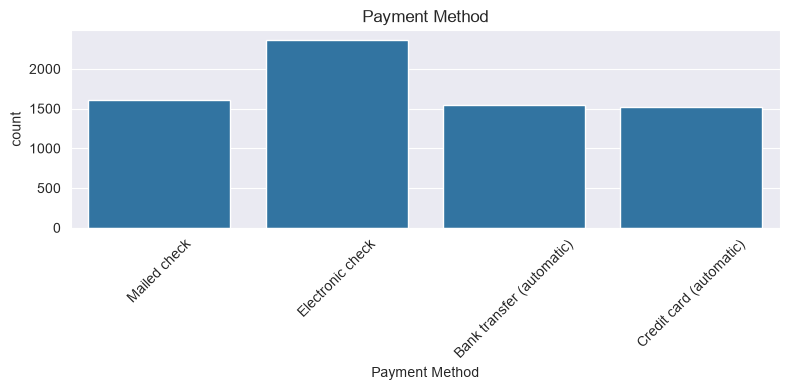

In [284]:
# ======================================================
# STEP 20 : Distribution of Categorical Features
# ======================================================

categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    if df[col].nunique() > 20:
        top = df[col].value_counts().head(20)
        sns.barplot(x=top.index, y=top.values)
        plt.xticks(rotation=90)
    else:
        sns.countplot(data=df, x=col)
        plt.xticks(rotation=45)

    plt.title(col)

    plt.tight_layout()

    plt.show()

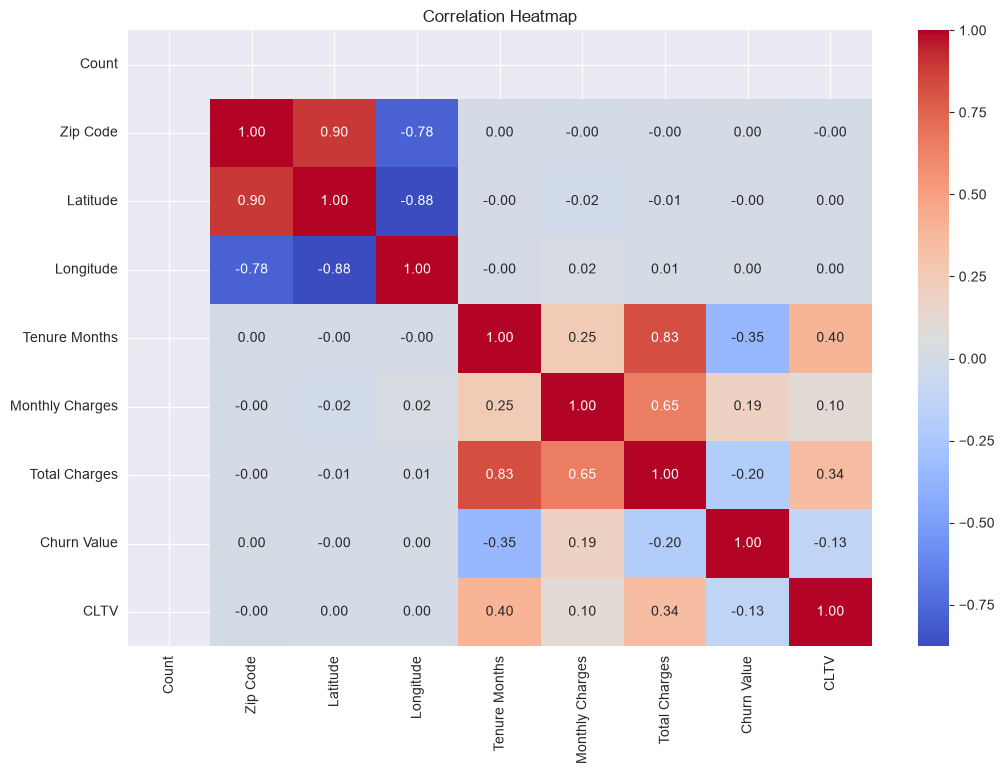

In [285]:
# ======================================================
# STEP 21 : Correlation Heatmap
# ======================================================

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

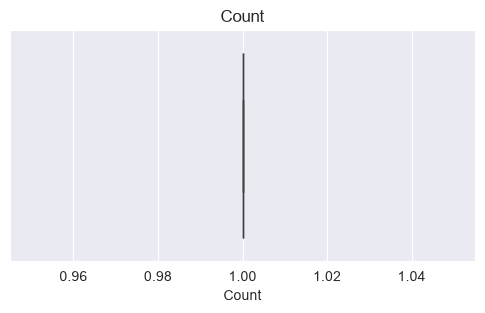

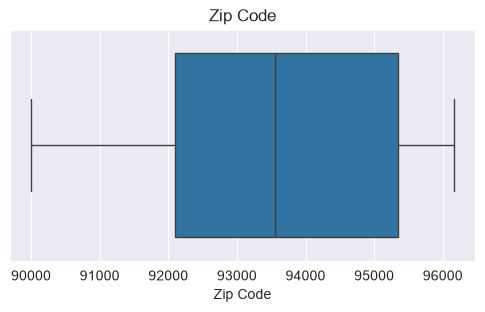

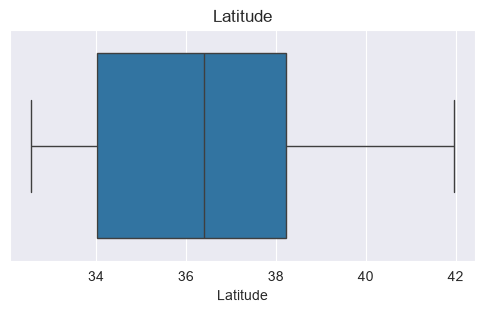

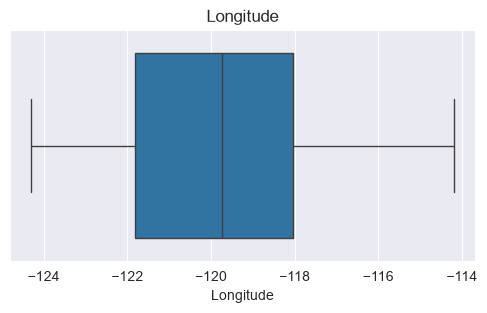

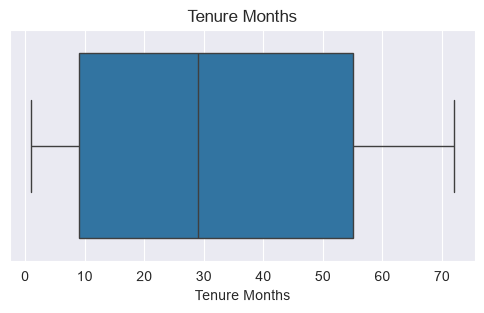

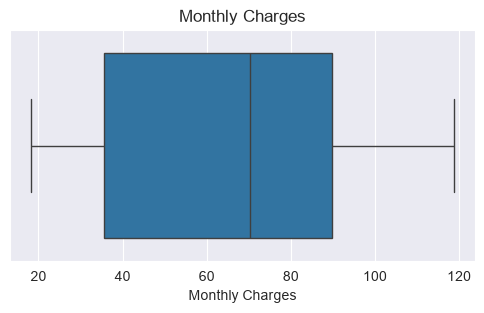

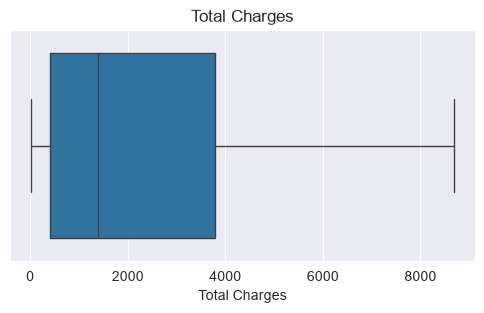

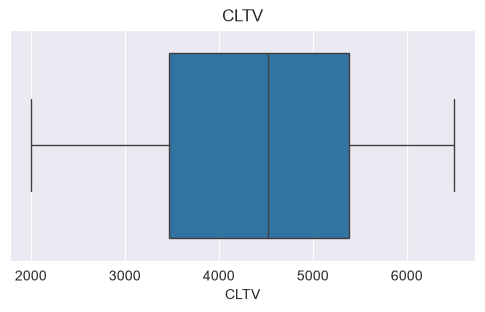

In [286]:
# ======================================================
# STEP 22 : Boxplots
# ======================================================

for col in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [287]:
# ======================================================
# STEP 23 : Skewness
# ======================================================

skewness = df[numerical_columns].skew()

display(skewness.sort_values(ascending=False))

Total Charges      0.961642
Latitude           0.303171
Tenure Months      0.237731
Count              0.000000
Longitude         -0.039741
Monthly Charges   -0.222103
Zip Code          -0.251658
CLTV              -0.311327
dtype: float64

In [288]:
# ======================================================
# STEP 24 : Unique Values
# ======================================================

for col in categorical_columns:

    print("="*60)

    print(col)

    print(df[col].unique())

    print()

Country
<StringArray>
['United States']
Length: 1, dtype: str

State
<StringArray>
['California']
Length: 1, dtype: str

City
<StringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Litchfield',        'Loyalton',        'Madeline',    'Markleeville',
         'Milford',         'Calpine',        'Standish',        'Tulelake',
  'Olympic Valley',        'Redcrest']
Length: 1129, dtype: str

Lat Long
<StringArray>
['33.964131, -118.272783',  '34.059281, -118.30742', '34.048013, -118.293953',
 '34.062125, -118.315709', '34.039224, -118.266293', '34.066367, -118.309868',
  '34.02381, -118.156582', '34.066303, -118.435479', '34.099869, -118.326843',
 '34.089953, -118.294824',
 ...
 '40.507272, -120.338228', '39.637471, -120.226338', '41.042003, -120.506086',
  '38.735789, -119.85798', '40.181279, -120.392967', '39.672813, -120.45

Churn Value
0    73.421502
1    26.578498
Name: proportion, dtype: float64


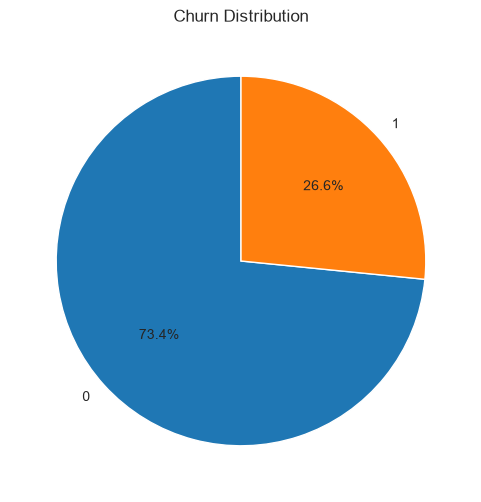

In [289]:
# ======================================================
# STEP 25 : Class Balance
# ======================================================

class_percent = y.value_counts(normalize=True)*100

print(class_percent)

plt.figure(figsize=(6,6))

plt.pie(
    class_percent,
    labels=class_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Churn Distribution")

plt.show()

In [290]:
# ======================================================
# STEP 26 : Drop Unnecessary Columns
# ======================================================

columns_to_drop = [
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

X = X.drop(columns=columns_to_drop)

print("Remaining Columns :", X.shape[1])

Remaining Columns : 21


In [291]:
# ======================================================
# STEP 27 : Remaining Features
# ======================================================

print(X.columns.tolist())

['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [292]:
# ======================================================
# STEP 28 : Numerical & Categorical Columns
# ======================================================

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include="object").columns

print("Numerical Features")

print(numerical_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
Index(['Count', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV'], dtype='str')

Categorical Features
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')


In [293]:
# ======================================================
# STEP 29 : Data Preprocessing Pipeline
# ======================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing Pipeline Ready ✅")

Preprocessing Pipeline Ready ✅


In [294]:
# ======================================================
# STEP 30 : Train Test Split
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)

print("Test Shape :", X_test.shape)

Train Shape : (5625, 21)
Test Shape : (1407, 21)


In [295]:
print("y values:")
print(y.value_counts())

print("\ny_train values:")
print(y_train.value_counts())

print("\ny_test values:")
print(y_test.value_counts())

y values:
Churn Value
0    5163
1    1869
Name: count, dtype: int64

y_train values:
Churn Value
0    4130
1    1495
Name: count, dtype: int64

y_test values:
Churn Value
0    1033
1     374
Name: count, dtype: int64


In [296]:
print(df["Churn Value"].value_counts(dropna=False))

Churn Value
0    5163
1    1869
Name: count, dtype: int64


In [297]:
print("df shape:", df.shape)

print("\ny:")
print(y.value_counts(dropna=False))

print("\ny_train:")
print(y_train.value_counts(dropna=False))

df shape: (7032, 29)

y:
Churn Value
0    5163
1    1869
Name: count, dtype: int64

y_train:
Churn Value
0    4130
1    1495
Name: count, dtype: int64


In [298]:
  # ======================================================
# STEP 31 : SMOTE
# ======================================================

from imblearn.over_sampling import SMOTE

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Churn Value
0    4130
1    1495
Name: count, dtype: int64

After SMOTE
Churn Value
0    4130
1    4130
Name: count, dtype: int64


In [299]:
print("df shape:", df.shape)

print("\ny:")
print(y.value_counts(dropna=False))

print("\ny_train:")
print(y_train.value_counts(dropna=False))

df shape: (7032, 29)

y:
Churn Value
0    5163
1    1869
Name: count, dtype: int64

y_train:
Churn Value
0    4130
1    1495
Name: count, dtype: int64


In [300]:
# ======================================================
# STEP 32 : Logistic Regression
# ======================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test_processed)

print("="*60)
print("Logistic Regression")
print("="*60)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy : 0.7370291400142146
Precision: 0.5034843205574913
Recall   : 0.7727272727272727
F1 Score : 0.609704641350211

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [301]:
# ======================================================
# STEP 33 : KNN
# ======================================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_smote, y_train_smote)

knn_pred = knn.predict(X_test_processed)

print("="*60)
print("KNN")
print("="*60)

print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))

print("\nClassification Report\n")
print(classification_report(y_test, knn_pred))

KNN
Accuracy : 0.6943852167732765
Precision: 0.4546925566343042
Recall   : 0.7513368983957219
F1 Score : 0.5665322580645161

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      1033
           1       0.45      0.75      0.57       374

    accuracy                           0.69      1407
   macro avg       0.67      0.71      0.67      1407
weighted avg       0.77      0.69      0.71      1407



In [302]:
# ======================================================
# STEP 34 : Decision Tree
# ======================================================

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test_processed)

print("="*60)
print("Decision Tree")
print("="*60)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy : 0.7185501066098081
Precision: 0.47417840375586856
Recall   : 0.5401069518716578
F1 Score : 0.505

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1033
           1       0.47      0.54      0.51       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.72      0.72      1407



In [303]:
# ======================================================
# STEP 35 : Random Forest
# ======================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test_processed)

print("="*60)
print("Random Forest")
print("="*60)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy : 0.7725657427149965
Precision: 0.5699481865284974
Recall   : 0.5882352941176471
F1 Score : 0.5789473684210527

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1033
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



In [304]:
# ======================================================
# STEP 36 : Gradient Boosting
# ======================================================

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_smote, y_train_smote)

gb_pred = gb.predict(X_test_processed)

print("="*60)
print("Gradient Boosting")
print("="*60)

print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, gb_pred))

Gradient Boosting
Accuracy : 0.7775408670931059
Precision: 0.5634095634095634
Recall   : 0.7245989304812834
F1 Score : 0.6339181286549708

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1033
           1       0.56      0.72      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



In [305]:
# ======================================================
# STEP 37 : Compare Models
# ======================================================

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]

})

display(comparison.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
4,Gradient Boosting,0.777541,0.563410,0.724599,0.633918
3,Random Forest,0.772566,0.569948,0.588235,0.578947
0,Logistic Regression,0.737029,0.503484,0.772727,0.609705
2,Decision Tree,0.718550,0.474178,0.540107,0.505000
1,KNN,0.694385,0.454693,0.751337,0.566532


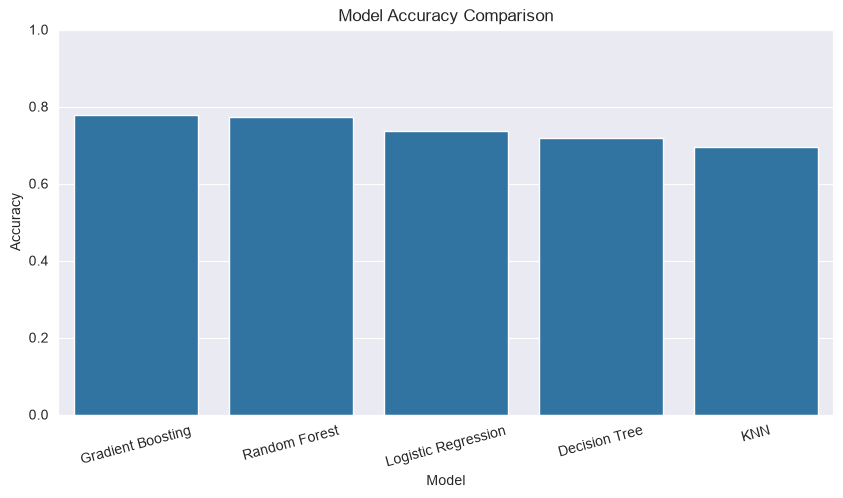

In [306]:
# ======================================================
# STEP 38 : Model Comparison
# ======================================================

comparison = comparison.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(data=comparison, x="Model", y="Accuracy")

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

In [307]:
# ======================================================
# STEP 39 : Grid Search for Random Forest
# ======================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_rf.best_params_)

print()

print("Best CV Accuracy:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Best CV Accuracy:
0.864406779661017


In [308]:
# ======================================================
# STEP 40 : Best Random Forest
# ======================================================

best_rf = grid_rf.best_estimator_

best_rf_pred = best_rf.predict(X_test_processed)

print(classification_report(y_test, best_rf_pred))

print("Accuracy :", accuracy_score(y_test, best_rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.57      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.78      1407

Accuracy : 0.7746979388770433


In [309]:
# ======================================================
# STEP 41 : Feature Importance
# ======================================================

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
1,num__Tenure Months,0.096302
3,num__Total Charges,0.083729
39,cat__Contract_Month-to-month,0.082153
2,num__Monthly Charges,0.077321
4,num__CLTV,0.073614
21,cat__Online Security_No,0.050742
46,cat__Payment Method_Electronic check,0.044923
30,cat__Tech Support_No,0.042019
12,cat__Dependents_Yes,0.034358
11,cat__Dependents_No,0.032316


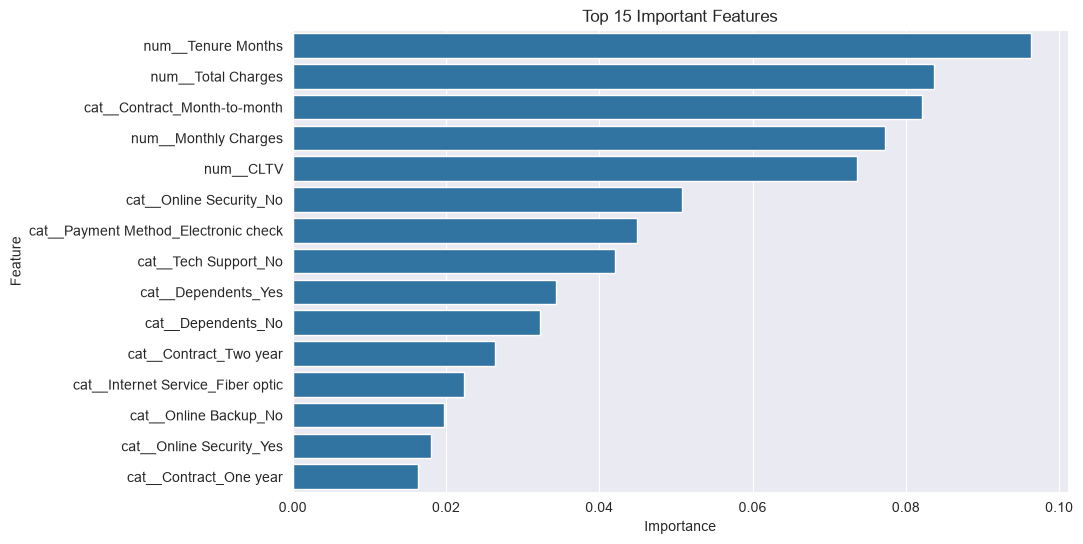

In [310]:
# ======================================================
# STEP 42 : Top 15 Features
# ======================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

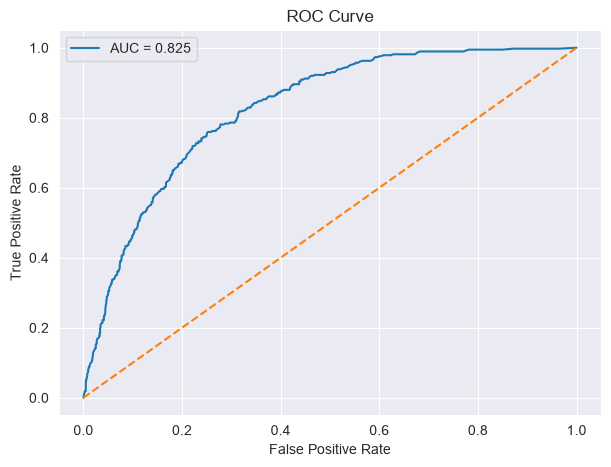

AUC Score : 0.8253076289919293


In [311]:
# ======================================================
# STEP 43 : ROC Curve
# ======================================================

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_rf.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score :", auc_score)

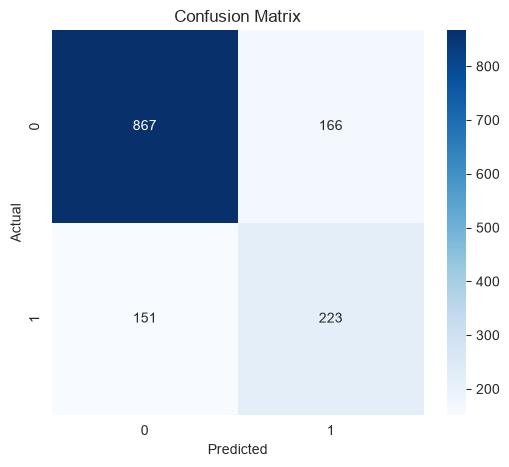

In [312]:
# ======================================================
# STEP 44 : Confusion Matrix
# ======================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [313]:
import joblib

joblib.dump(best_rf, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model saved successfully!")

Model saved successfully!
